> ### Public copy — demo data
>
> The 2024 survey this project was built on belongs to the client and is not redistributable, so
> it is **not in this repository**. In its place, `data/raw/engagement_survey_2024.xlsx` is written
> by `scripts/make_demo_workbook.py`: the same sheet name, the same 22 columns and 42 rows, the
> same category headers, the same two 1-10 items and the same delta-from-company-mean encoding —
> and **entirely invented numbers**.
>
> So: the code, the method choices and the reasoning below are the originals. Every number, table
> and chart is computed from demo data, and every Phase 1 figure is badged **DEMO** instead of
> REAL. Where a passage describes what was actually found on the client's data it says so and
> points to the section of the accompanying report that carries the figures.
>
> `data.provenance` in `config/config.yaml` is the switch: set it to `real` once the client
> workbook is in place, and the badges change back.

# NB02 — Phase 1: Diagnostic Analysis

| | |
|---|---|
| **Purpose** | The current engagement picture: where the company stands, where the problems sit, and what kind of problem each one is (RO1, RO3a). |
| **Input** | harmonised scores from NB01 |
| **Outputs** | `fig01` `fig02` `fig02b` `fig02c` · `tab03`–`tab07` |
| **Evidence for essay** | §3.1 (**Figure 2** = `fig01`) · §3.2 (**Figure 3** = `fig02`, **Appendix D1** = `tab05`) · §3.3 (**Figure 4** = `fig02b`, **Table 2** = `tab06`) · §3.4 (**Figure 5** = `fig02c`, **Appendix B4** = `tab07`) |

In the original study every result in this notebook is a **fact about the client**, within the
boundary stated in NB01. In this public copy the same cells run against the demo workbook, so the
numbers are invented and the figures are badged DEMO — the boundary argument itself is unchanged,
and it is the argument that matters.

In [1]:
# Environment — package installed via `pip install -e .`; path fallback for direct runs
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from engagement import io, quality, phase1, viz
from engagement.config import load_config

cfg = load_config()
pd.set_option("display.max_colwidth", 90)

# rebuild the harmonised dataset from source (same functions the pipeline uses)
harmonised = quality.harmonise_scales(
    quality.reconstruct_absolute(io.tidy(io.load_heatmap(cfg), cfg)), cfg)
print(f"harmonised rows: {len(harmonised)}")

harmonised rows: 680


---
## 1 · Where do we stand, and on what? · essay §3.1

**Decision box**

| | |
|---|---|
| **What** | Recompute the eight theme means from harmonised items and rank them. |
| **Why this method** | A ranked profile answers the client's first question in one view. Recomputing is necessary, not cosmetic: the workbook's own headers are not comparable across themes (NB01). |
| **Alternative rejected** | Reusing the workbook's category rows, two of them mix 1–5 and 1–10 items. |
| **Feeds** | `tab03`, `fig01` → essay **Figure 2**; the performance axis of the IPMA in NB03. |

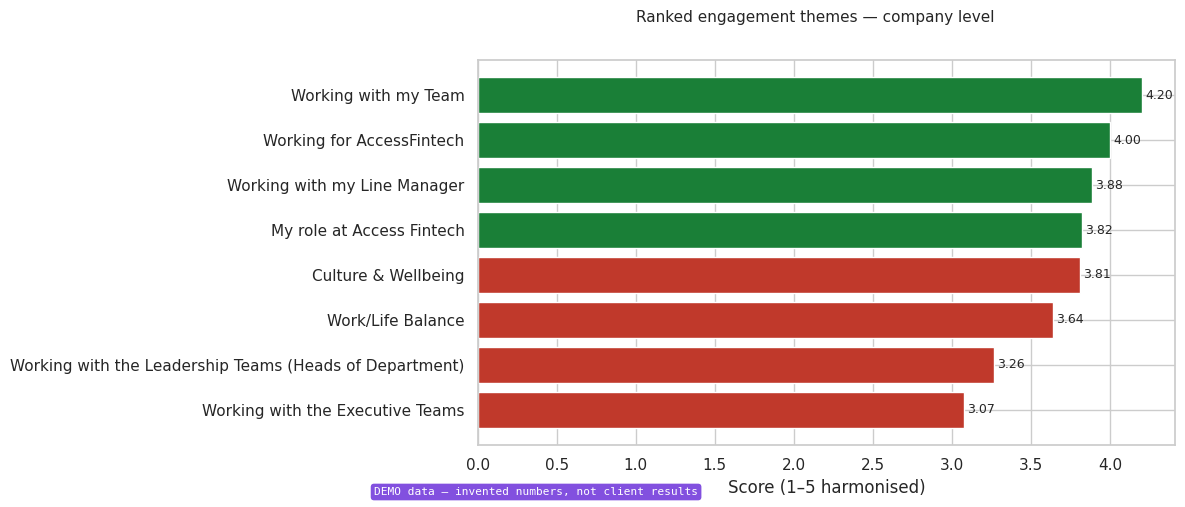

company mean across themes : 3.71
ranking span (max − min)   : 1.13


,mean,n_items,rank
category,,,
Working with my Team,4.200,3,1
Working for AccessFintech,3.997,6,2
Working with my Line Manager,3.884,5,3
My role at Access Fintech,3.823,6,4
Culture & Wellbeing,3.810,5,5
Work/Life Balance,3.640,3,6
Working with the Leadership Teams (Heads of Department),3.263,3,7
Working with the Executive Teams,3.073,3,8


In [2]:
ranking = phase1.theme_ranking(harmonised)

fig, ax = plt.subplots(figsize=(9, 5))
viz.ranked_bar(ranking["mean"], ax=ax)
viz.save_figure(fig, "fig01_theme_ranking", cfg, "real",
                "Ranked engagement themes — company level")
plt.show()

# headline numbers quoted in essay §3.1
print(f"company mean across themes : {ranking['mean'].mean():.2f}")
print(f"ranking span (max − min)   : {ranking['mean'].max() - ranking['mean'].min():.2f}")
ranking

**What the ranking is read for (essay §3.1).** Its *shape*, not its level. The themes covering
the immediate working environment — own team, own role, own manager — sit above those covering the
organisationally distant layers, heads of department and the executive. That ordering is the
common one in engagement surveys and it is not the useful part of the chart.

The useful part is how little of the survey's total variation the eight themes account for
compared with the spread *between departments* (quantified in section 4 below and in NB03 §D). If
a company-level theme ranking compresses into a narrow band, it is a poor place to aim an
intervention — which is why the next three sections move down to department and then item level.

The client's theme scores are reported in §3.1 of the accompanying report.

---
## 2 · Where do the problems sit? · essay §3.2

**Decision box**

| | |
|---|---|
| **What** | Average each department's harmonised items up to the eight themes, then subtract the company theme mean, a 19 × 8 grid of deviations. |
| **Why this method** | Locates *where* concern concentrates. Reading the grid across its rows gives each department a shape, not just a rank. |
| **Alternative rejected** | A single-average department league table, hides which themes drive a department's position, which is the actionable part. |
| **Feeds** | `tab04`, `fig02` → essay **Figure 3**. |

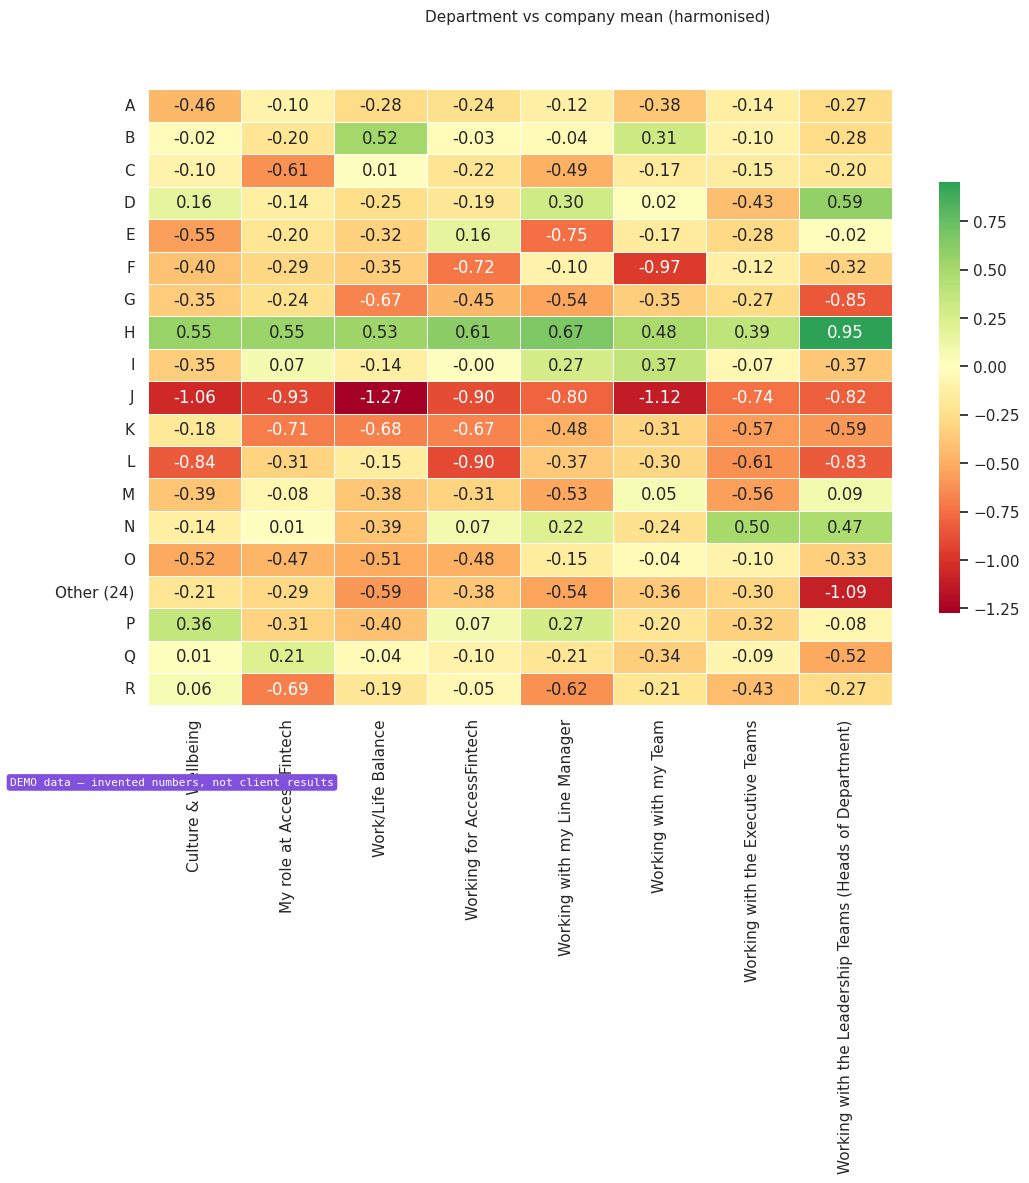

category,Culture & Wellbeing,My role at Access Fintech,Work/Life Balance,Working for AccessFintech,Working with my Line Manager,Working with my Team,Working with the Executive Teams,Working with the Leadership Teams (Heads of Department)
department,,,,,,,,
A,-0.46,-0.10,-0.28,-0.24,-0.12,-0.38,-0.14,-0.27
B,-0.02,-0.20,0.52,-0.03,-0.04,0.31,-0.10,-0.28
C,-0.10,-0.61,0.01,-0.22,-0.49,-0.17,-0.15,-0.20
D,0.16,-0.14,-0.25,-0.19,0.30,0.02,-0.43,0.59
E,-0.55,-0.20,-0.32,0.16,-0.75,-0.17,-0.28,-0.02
F,-0.40,-0.29,-0.35,-0.72,-0.10,-0.97,-0.12,-0.32
G,-0.35,-0.24,-0.67,-0.45,-0.54,-0.35,-0.27,-0.85
H,0.55,0.55,0.53,0.61,0.67,0.48,0.39,0.95
I,-0.35,0.07,-0.14,-0.00,0.27,0.37,-0.07,-0.37


In [3]:
gaps = phase1.gap_matrix(harmonised)

fig, ax = plt.subplots(figsize=(12, 8))
viz.heatmap(gaps, ax=ax)
viz.save_figure(fig, "fig02_department_gap_heatmap", cfg, "real",
                "Department vs company mean (harmonised)")
plt.show()
gaps.round(2)

**Decision box**

| | |
|---|---|
| **What** | Rank every department × item deviation and return the eight largest in each direction. |
| **Why this method** | A theme average can hide one bad question inside a good theme. Looking at single questions finds departments that look fine at theme level. |
| **Alternative rejected** | Stopping at the theme grid. Five of the eight worst question-level gaps sit inside the company's *highest-scoring* theme, so they would never have appeared. |
| **Feeds** | `tab05` → essay **Appendix D1**; named owners for the §6 recommendations. |

In [4]:
top = phase1.top_gaps(harmonised, n=8)
top

,department,category,item,harmonised,company_score,gap,direction
160,H,My role at Access Fintech,AFT places great importance on the growth and development of its people.,4.790000,3.770000,1.020,above
540,H,Working with the Leadership Teams (Heads of Department),The Leadership team openly and transparently updates employees on decisions and change...,4.160000,3.140000,1.020,above
103,H,Working for AccessFintech,How happy are you at AccessFintech on a scale of 1 to 10?,4.822222,3.844444,0.978,above
559,H,Working with the Leadership Teams (Heads of Department),The leadership team values all employees and treats them equally with fairness and res...,4.320000,3.380000,0.940,above
578,H,Working with the Leadership Teams (Heads of Department),My work is appreciated by my Head of Department.,4.170000,3.270000,0.900,above
565,N,Working with the Leadership Teams (Heads of Department),The leadership team values all employees and treats them equally with fairness and res...,4.220000,3.380000,0.840,above
464,H,Working with my Line Manager,My work is appreciated by my direct manager.,4.770000,3.950000,0.820,above
388,H,Working with my Line Manager,My manager keeps me informed about what is happening within my team and the wider busi...,4.730000,3.930000,0.800,above
352,J,Work/Life Balance,I feel AFT is supportive of a healthy work-life balance.,1.700000,3.580000,-1.880,below
523,J,Working with my Team,Collaboration between departments/teams is done well at Access Fintech.,2.600000,4.200000,-1.600,below


**What this grid is read for (essay §3.2).** Three patterns, and the third is the one that
changes what you would do about it.

1. **Clusters of large positive gaps.** Useful as internal benchmarks — which department already
   does this well and could be asked how — rather than as a league table.
2. **Two departments, one theme average, opposite problems.** One can carry a single deep cell
   while the rest of its row sits at or above the company mean; another can be broadly and evenly
   below. The first is a local problem with a named owner, the second a departmental climate
   problem, and they need different responses. A theme-level average cannot tell them apart.
3. **Large negative gaps at *item* level inside a high-scoring theme**, sometimes in departments
   whose theme-level gap looks unremarkable. This is the case that matters most, because
   aggregation hides exactly the cells an intervention would target.

The departments and gap sizes found on the client data are in §3.2 and Appendix D1 of the
accompanying report.

---
## 3 · What *kind* of problem is each one? · essay §3.3

Section 2 read the grid across its rows. Read down its columns, the same grid asks a different
question of every item: is a low score a few departments dragging the average down, or every
department scoring badly? The two need different interventions.

**Decision box**

| | |
|---|---|
| **What** | Score every item on two axes, company mean and spread across the 19 departments and assign it to one of four quadrants. |
| **Why this method** | A low mean with **wide** spread is localised (targeted action); a low mean with **narrow** spread is company-wide (policy fix). Same low score, different response. Both cut-offs are quantiles fixed in `config.yaml` **before any result was seen**. |
| **Alternative rejected** | Flagging on low mean alone, conflates the two problem types and produces one undifferentiated list. |
| **Feeds** | `tab06` → essay **Table 2**; `fig02b` → essay **Figure 4**; the §6 targeting. |

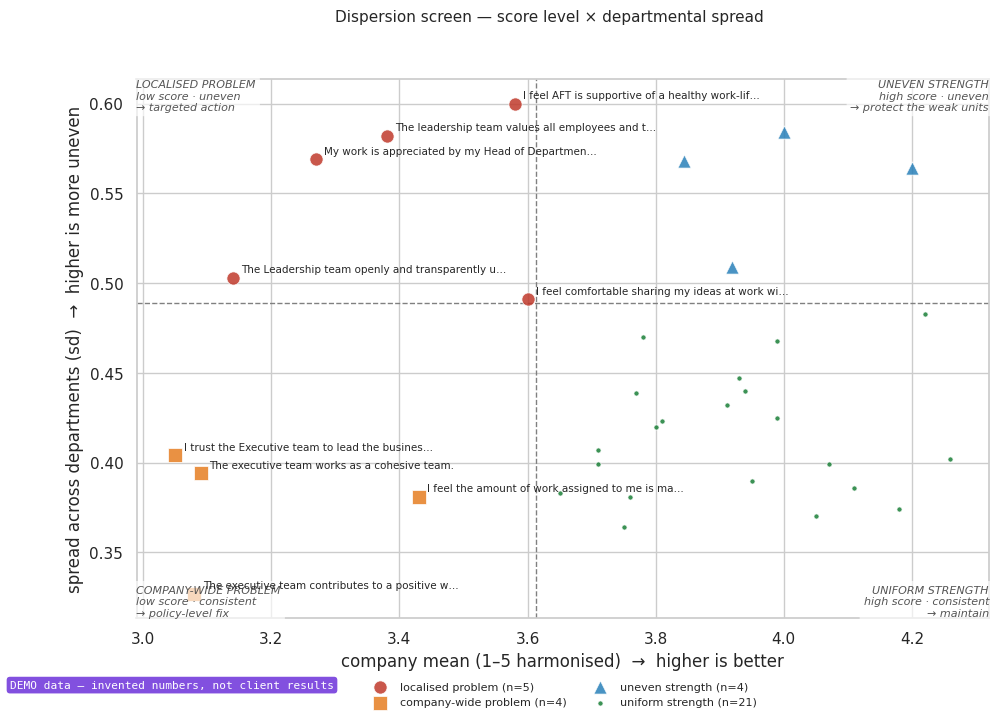

low-mean cut-off   : 3.612
wide-spread cut-off: 0.489
priority items     : 9 of 34

quadrant
uniform strength        21
localised problem        5
company-wide problem     4
uneven strength          4


In [5]:
disp = phase1.dispersion_screen(harmonised, cfg)

fig, ax = plt.subplots(figsize=(11, 7))
viz.dispersion_quadrants(disp, cfg, ax=ax)
viz.save_figure(fig, "fig02b_dispersion_quadrants", cfg, "real",
                "Dispersion screen — score level × departmental spread")
plt.show()

# cut-offs and counts quoted in essay §3.3
print(f"low-mean cut-off   : {disp['company_mean'].quantile(cfg['phase1']['low_mean_quantile']):.3f}")
print(f"wide-spread cut-off: {disp['spread'].quantile(cfg['phase1']['dispersion_high_spread_quantile']):.3f}")
print(f"priority items     : {int(disp['priority_2026'].sum())} of {len(disp)}\n")
print(disp["quadrant"].value_counts().to_string())

In [6]:
disp[disp["priority_2026"]][["company_mean", "spread", "dept_min", "quadrant"]]

company_mean  \
category                                                item                                                                                                       
Work/Life Balance                                       I feel AFT is supportive of a healthy work-life balance.                                            3.58   
Working with the Leadership Teams (Heads of Department) The leadership team values all employees and treats them equally with fairness and resp...          3.38   
                                                        My work is appreciated by my Head of Department.                                                    3.27   
                                                        The Leadership team openly and transparently updates employees on decisions and changes...          3.14   
Culture & Wellbeing                                     I feel comfortable sharing my ideas at work with peers and management.                              3.60   
Working with the Executive Teams                        I trust the Executive team to lead the business to success.                                         3.05   
                                                        The executive team works as a cohesive team.                                                        3.09   
Work/Life Balance                                       I feel the amount of work assigned to me is manageable                                              3.43   
Working with the Executive Teams                        The executive team contributes to a positive work culture.                                          3.08   

                                                                                                                                                    spread  \
category                                                item                                                                                                 
Work/Life Balance                                       I feel AFT is supportive of a healthy work-life balance.                                     0.600   
Working with the Leadership Teams (Heads of Department) The leadership team values all employees and treats them equally with fairness and resp...   0.582   
                                                        My work is appreciated by my Head of Department.                                             0.569   
                                                        The Leadership team openly and transparently updates employees on decisions and changes...   0.503   
Culture & Wellbeing                                     I feel comfortable sharing my ideas at work with peers and management.                       0.491   
Working with the Executive Teams                        I trust the Executive team to lead the business to success.                                  0.404   
                                                        The executive team works as a cohesive team.                                                 0.394   
Work/Life Balance                                       I feel the amount of work assigned to me is manageable                                       0.381   
Working with the Executive Teams                        The executive team contributes to a positive work culture.                                   0.327   

                                                                                                                                                    dept_min  \
category                                                item                                                                                                   
Work/Life Balance                                       I feel AFT is supportive of a healthy work-life balance.                                        1.70   
Working with the Leadership Teams (Heads of Department) The leadership team values all employees and treats them equally wit

**What the quadrant screen establishes (essay §3.3).** It turns "which items score badly" into
"what *kind* of badly", and the two diagnoses call for different responses: an item that is low in
every department is a company-wide policy or design problem, while an item that is low in only a
few is a local delivery problem. Averaging the two together produces an intervention that fits
neither.

The sharper result is usually in the fourth quadrant — items with a **high** mean and a **wide**
spread. A strong theme average can coexist with very uneven delivery of that theme, and the
widest-spread item in a survey is often found inside its highest-scoring one. Uneven strengths
appear in no ranking of means, which is the whole argument for screening on spread as well as
level.

The nine items this identified on the client data, and their split between company-wide and
localised, are in Table 2 / `tab06` of the accompanying report.

---
## 4 · Eight themes, or one? · essay §3.4 (opening evidence)

**Decision box**

| | |
|---|---|
| **What** | Correlate the eight theme scores with each other across the 19 department units. |
| **Why this method** | Shows which themes move together, generating hypotheses for the Phase 2 driver work. |
| **Alternative rejected** | **Any inferential reading is prohibited here.** ~19 units gives very low power (\|r\| ≈ 0.46 to clear p < .05), estimates are unstable, and ecological inference does not license individual-level claims. |
| **Feeds** | `tab07`, `fig02c` → essay **Figure 5**; the halo argument continued in NB03. |


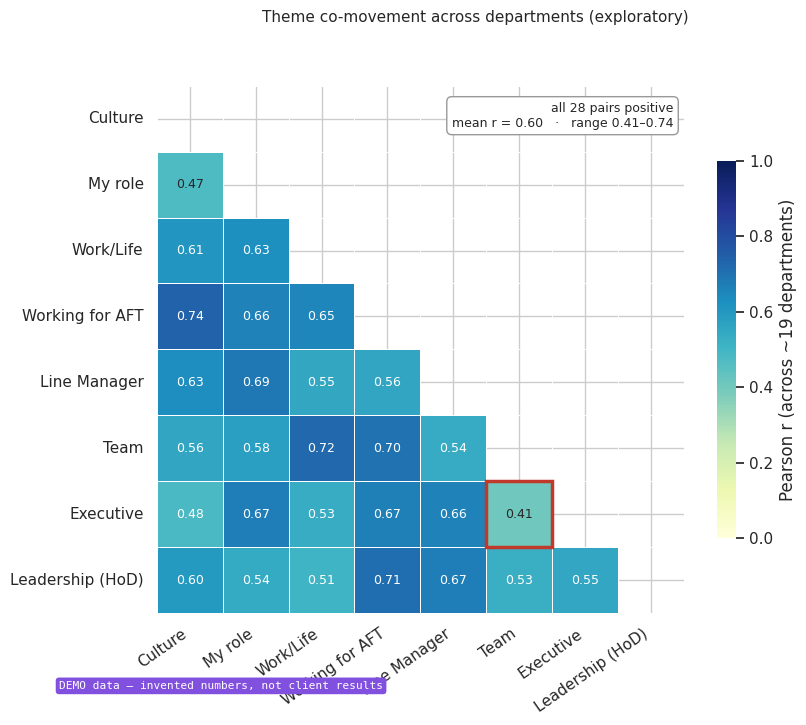

category,Culture,My role,Work/Life,Working for AFT,Line Manager,Team,Executive,Leadership (HoD)
category,,,,,,,,
Culture,1.000,0.474,0.606,0.740,0.632,0.558,0.481,0.597
My role,0.474,1.000,0.627,0.661,0.685,0.576,0.671,0.542
Work/Life,0.606,0.627,1.000,0.649,0.550,0.725,0.534,0.506
Working for AFT,0.740,0.661,0.649,1.000,0.558,0.703,0.667,0.710
Line Manager,0.632,0.685,0.550,0.558,1.000,0.537,0.661,0.670
Team,0.558,0.576,0.725,0.703,0.537,1.000,0.408,0.526
Executive,0.481,0.671,0.534,0.667,0.661,0.408,1.000,0.553
Leadership (HoD),0.597,0.542,0.506,0.710,0.670,0.526,0.553,1.000


In [7]:
corr = phase1.theme_correlation(harmonised)

fig, ax = plt.subplots(figsize=(8.5, 7))
viz.correlation_triangle(corr, ax=ax)
viz.save_figure(fig, "fig02c_theme_correlation", cfg, "real",
                "Theme co-movement across departments (exploratory)")
plt.show()

corr.rename(index=viz.SHORT_CATEGORY, columns=viz.SHORT_CATEGORY)

**What the correlation matrix establishes (essay §3.4).** Two features matter, and neither is an
inferential claim: with ~19 aggregated units, |r| must reach roughly 0.46 to clear p < .05, so
these are hypotheses for Phase 2 rather than results.

- **Near-universal positive correlation** between theme pairs is the first of three signs of a
  general favourability factor — a halo, where departments that rate one thing well rate
  everything well. NB03 tests it directly with PCA and with an independent composite index.
- **The exceptions carry the information.** A pair that is close to independent suggests two
  genuinely separate levers rather than one. A pair that is unusually high deserves a check for a
  *measurement* explanation before a substantive one — the two themes containing the 1–10 items
  are the ones to suspect, which is the NB01 scale defect resurfacing inside a result.

Coefficients for the client data are in Appendix B4 / `tab07` of the accompanying report.

In [8]:
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"]); t.mkdir(parents=True, exist_ok=True)
ranking.to_csv(t / "tab03_theme_ranking.csv")
gaps.to_csv(t / "tab04_gap_matrix.csv")
top.to_csv(t / "tab05_top_gaps.csv", index=False)
disp.to_csv(t / "tab06_dispersion_screen.csv")
corr.to_csv(t / "tab07_theme_correlation.csv")
print("tab03 · tab04 · tab05 · tab06 · tab07")

tab03 · tab04 · tab05 · tab06 · tab07


---
**Next:** `03_phase1_multivariate.ipynb`: does the eight-theme structure hold, and can the
departments be grouped? (essay §3.4–3.5)